In [ ]:
#!git clone https://github.com/whyhardt/SPICE.git

In [ ]:
# !pip install -e SPICE

In [1]:
import sys
import torch

from spice import SpiceEstimator, csv_to_dataset, split_data_along_sessiondim, BaseModel
from spice.precoded import workingmemory

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from benchmarking_dezfouli2019 import GQLModel, get_dataset, generate_behavior

from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals
from analysis_generative import analysis_generative_behavior

## Load dataset

In [2]:
path_data = 'data/dezfouli2019.csv'
test_sessions = (3, 6, 9)
dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_sessions=test_sessions, verbose=True)

Shape of dataset: torch.Size([1212, 202, 1, 9])
Number of participants: 101
Number of actions in dataset: 2


## SPICE Training

Let's setup now the `SpiceEstimator` object and fit it to the data! 

We are going to do this in two steps:

1. Without fitting the SINDy coefficients to get the pure RNN performance given the selected architecture. 
2. With fitting SINDy coefficients to get the final performance of the interpretable model

That way we can disentangle the gap between GRU and SPICE w.r.t. architecture and SINDy library 

In [ ]:
# fitting without SINDy coefficients

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=workingmemory.SpiceModel,
        spice_config=workingmemory.CONFIG,
        n_actions=info_dataset['n_actions'],
        n_participants=info_dataset['n_participants'],
        
        epochs=1000,
        warmup_steps=200,
        sindy_weight=0,
        
        verbose=True,
    )
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [4]:
path_spice = 'params/spice_dezfouli2019.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=workingmemory.SpiceModel,
        spice_config=workingmemory.CONFIG,
        n_actions=info_dataset['n_actions'],
        n_participants=info_dataset['n_participants'],
        kwargs_spice_class={'reward_binary': True},
        
        epochs=1000,
        warmup_steps=200,
        ensemble_size=10,
        
        sindy_weight=0.1,
        sindy_alpha=0.0001,
        sindy_pruning_frequency=100,
        sindy_threshold_pruning=0.01,
        sindy_ensemble_pruning=0.05,
        sindy_library_polynomial_degree=2,
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        verbose=True,
        save_path_spice=path_spice,
    )

In [ ]:
estimator.fit(dataset_train.xs, dataset_train.ys, dataset_train.xs, dataset_train.ys)

In [ ]:
estimator.load_spice(path_spice)
estimator.set_device(torch.device('cpu'))

In [ ]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=0)

## Benchmarking

### Generalized Q-Learning Model by Dezfouli (2019)

In [ ]:
# 1. stick to low effort 
# 2. two sets of params for low and high effort

gql = GQLModel(
    n_participants=info_dataset['n_participants'],
    batch_first=True,
    )

path_gql = path_spice.replace('spice_', 'gql_')

In [ ]:
epochs = 1000
optimizer = torch.optim.Adam(params=gql.parameters(), lr=0.01)

gql = training(
    model=gql,
    optimizer=optimizer,
    epochs=epochs,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    device=torch.device('cpu'),
)

torch.save(gql.state_dict(), path_gql)

In [6]:
gql.load_state_dict(torch.load(path_gql, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [9]:
gru = GRUModel(
    n_actions=info_dataset['n_actions'], 
    n_participants=info_dataset['n_participants'],
    additional_inputs=2, 
    dropout=0.25,
    embedding_size=8,
    hidden_size=8,
    )
path_gru = path_spice.replace('spice_', 'gru_')

In [11]:
epochs = 2000
optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

gru = training(
    model=gru,
    optimizer=optimizer,
    dataset_train=dataset_train,
    dataset_test=dataset_test,
    epochs=epochs,
    ).to(torch.device('cpu'))

torch.save(gru.state_dict(), path_gru)

Epoch 1/2000: L(Train): 0.38217249512672424; L(Test): 0.3731473386287689
Epoch 2/2000: L(Train): 0.3998495936393738; L(Test): 0.38000380992889404
Epoch 3/2000: L(Train): 0.4057343006134033; L(Test): 0.36829516291618347
Epoch 4/2000: L(Train): 0.38750892877578735; L(Test): 0.3675287365913391
Epoch 5/2000: L(Train): 0.383908212184906; L(Test): 0.3686986565589905
Epoch 6/2000: L(Train): 0.3861521780490875; L(Test): 0.3692241311073303
Epoch 7/2000: L(Train): 0.38663679361343384; L(Test): 0.367929607629776
Epoch 8/2000: L(Train): 0.38434675335884094; L(Test): 0.3673577606678009
Epoch 9/2000: L(Train): 0.3828772306442261; L(Test): 0.367725133895874
Epoch 10/2000: L(Train): 0.3829413652420044; L(Test): 0.3679855465888977
Epoch 11/2000: L(Train): 0.38165751099586487; L(Test): 0.3674085736274719
Epoch 12/2000: L(Train): 0.38242000341415405; L(Test): 0.36613476276397705
Epoch 13/2000: L(Train): 0.3817377984523773; L(Test): 0.3646160662174225
Epoch 14/2000: L(Train): 0.38043710589408875; L(Test):

In [8]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))
gru.eval()

Model(
  (linear_in): Linear(in_features=4, out_features=16, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (gru): GRUModel(16, 16, batch_first=True)
  (linear_out): Linear(in_features=16, out_features=2, bias=True)
)

# ANALYSIS

## Analysis model evaluation

In [14]:
analysis_model_evaluation(
    dataset=dataset_test,
    # spice_model=estimator,
    # benchmark_model=gql.to(torch.device('cpu')),
    gru_model=gru.to(torch.device('cpu')),
)

Computing choice probabilities with GRU model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000
GRU,0.761157,0.137141,1386.0,0.0,9149.235352,21070.470703,32740.613281
SPICE-RNN,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000
SPICE,1.000000,0.000000,NaN,0.0,0.000000,0.000000,0.000000


## Analysis coefficient distributions

In [ ]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

## Analysis Individual Differences

In [ ]:
analysis_coefficients_individuals(
    criterion="diag",
    analysis="disc",  # also: "cont"
    reference="Control",  # only necessary if analysis="disct"
    
    path_data=path_data,
    
    spice_model=estimator,
    
    dir_output='results',
)

## Analysis generative behavior

In [12]:
generate_behavior(
    model=gql,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_gql.csv',
)

generate_behavior(
    model=gru,
    dataset=dataset_train,
    save_dataset='data/dezfouli2019_gru.csv',
)

Generating behavior...


  0%|          | 0/202 [00:00<?, ?it/s]

100%|██████████| 202/202 [00:00<00:00, 531.14it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 202/202 [00:00<00:00, 914.04it/s]


Done generating behavior.


Loading real from data/dezfouli2019.csv...
Loading benchmark from data/dezfouli2019_gql.csv...
Loading gru from data/dezfouli2019_gru.csv...
            Average Reward      Total Reward  ...   P(Stay | Loss)          P(Stay)
Model                                         ...                                  
real       0.112 +/- 0.051  11.720 +/- 5.731  ...  0.780 +/- 0.295  0.771 +/- 0.284
benchmark  0.112 +/- 0.062  11.758 +/- 7.593  ...  0.793 +/- 0.237  0.789 +/- 0.235
gru        0.121 +/- 0.070  12.542 +/- 8.157  ...  0.838 +/- 0.230  0.828 +/- 0.223

[3 rows x 5 columns]


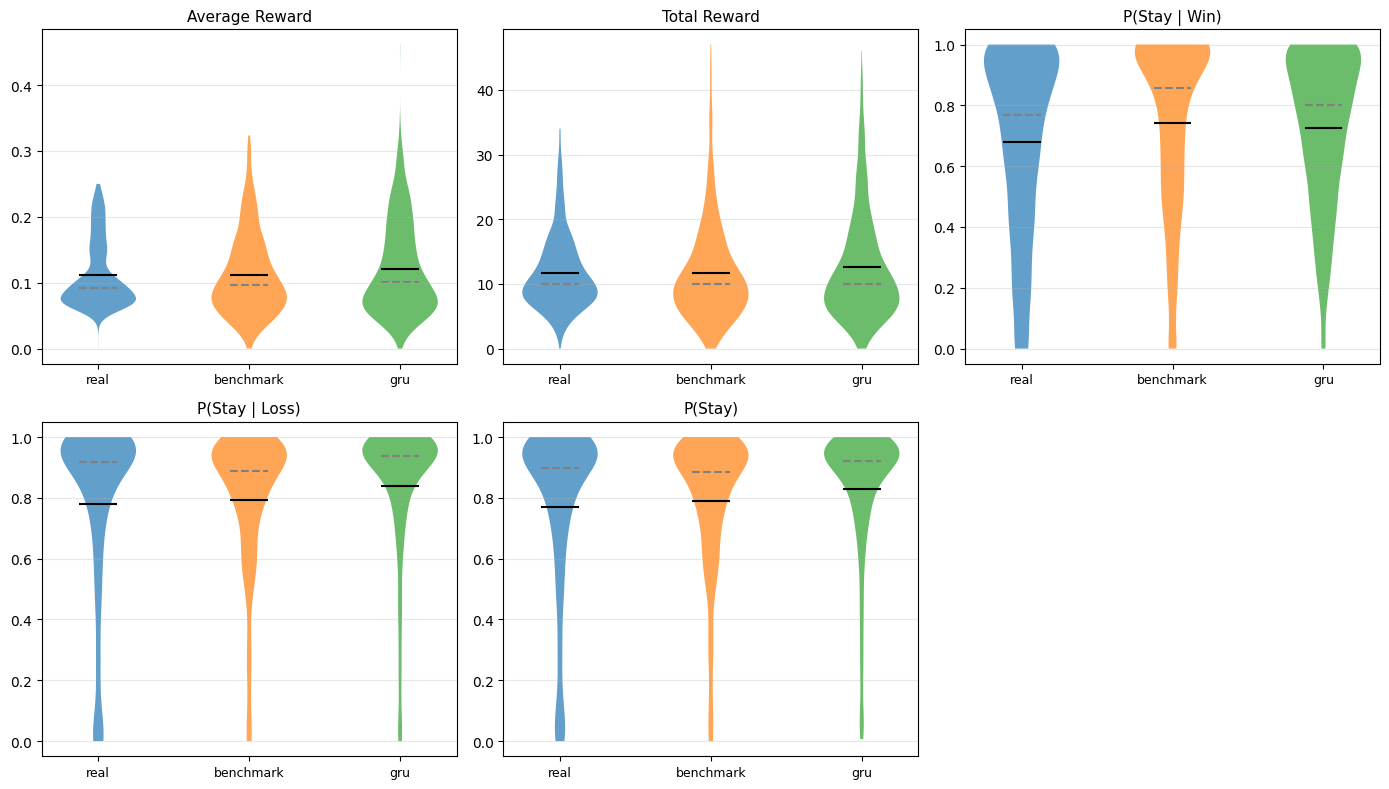

,Average Reward,Total Reward,P(Stay | Win),P(Stay | Loss),P(Stay)
Model,,,,,
real,0.112 +/- 0.051,11.720 +/- 5.731,0.678 +/- 0.300,0.780 +/- 0.295,0.771 +/- 0.284
benchmark,0.112 +/- 0.062,11.758 +/- 7.593,0.742 +/- 0.290,0.793 +/- 0.237,0.789 +/- 0.235
gru,0.121 +/- 0.070,12.542 +/- 8.157,0.726 +/- 0.248,0.838 +/- 0.230,0.828 +/- 0.223


In [13]:
analysis_generative_behavior(
    path_data_real=path_data,
    path_data_benchmark='data/dezfouli2019_gql.csv',
    path_data_gru='data/dezfouli2019_gru.csv',
)

# EXPERIMENT EMBEDDING

## Dataset setup

In [ ]:
path_data = 'data/dezfouli2019_experimentid.csv'
dataset = csv_to_dataset(file = path_data)

n_actions = dataset.ys.shape[-1]
n_participants = dataset.xs[..., -1].unique().shape[0]
n_experiments = dataset.xs[..., -2].unique().shape[0]
print(f"Number of participants: {n_participants}")
print(f"Number of experiments: {n_experiments}")

test_sessions = (3, 6, 9)
dataset_train, dataset_test = split_data_along_sessiondim(dataset, test_sessions)

## Spice Setup

In [ ]:
class SpiceEmbModel(BaseModel):
    """
    Working memory as explicit buffer of recent rewards.
    
    Key difference from value learning:
    - Stores individual past rewards (not aggregated statistics)
    - Fixed capacity (buffer size)
    - Perfect memory for items in buffer
    - Items fall out of buffer (discrete forgetting)
    """
    
    def __init__(self, reward_binary: bool = False, **kwargs):
        super().__init__(**kwargs)
        
        dropout = 0.1
        
        self.participant_embedding = self.setup_embedding(self.n_participants, self.embedding_size, dropout=dropout)
        self.experiment_embedding = self.setup_embedding(self.n_experiments, 2, dropout=dropout)
        
        # Value learning module (slow updates)
        # Can use recent reward history to modulate learning
        self.setup_module(key_module='value_reward_chosen', input_size=4+self.embedding_size+2, dropout=dropout)  # -> 21 terms
        self.setup_module(key_module='value_reward_not_chosen', input_size=3+self.embedding_size+2, dropout=dropout)  # -> 21 terms
        
        # self.setup_module(key_module='value_choice', input_size=4+self.embedding_size, dropout=dropout, include_bias=True) # -> 21 terms; bias not necessary when module is applied equally to all options
        self.setup_module(key_module='value_choice_chosen', input_size=3+self.embedding_size+2, dropout=dropout) # -> 21 terms; bias not necessary when module is applied equally to all options
        self.setup_module(key_module='value_choice_not_chosen', input_size=3+self.embedding_size+2, dropout=dropout) # -> 21 terms; bias not necessary when module is applied equally to all options
        
        self.preprocess_coefficients(reward_binary=reward_binary)
        
    def forward(self, inputs, prev_state=None):
        spice_signals = self.init_forward_pass(inputs, prev_state)

        # perform time-invariant computations
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        experiment_embedding = self.experiment_embedding(spice_signals.experiment_ids)

        for trial in spice_signals.trials:
            
            # REWARD VALUE UPDATES
            self.call_module(
                key_module='value_reward_chosen',
                key_state='value_reward',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    spice_signals.rewards[trial],
                    self.state['buffer_reward_1'],
                    self.state['buffer_reward_2'],
                    self.state['buffer_reward_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            self.call_module(
                key_module='value_reward_not_chosen',
                key_state='value_reward',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_reward_1'],
                    self.state['buffer_reward_2'],
                    self.state['buffer_reward_3'],
                    ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            # CHOICE VALUE UPDATES
            # self.call_module(
            #     key_module='value_choice',
            #     key_state='value_choice',
            #     action_mask=None,
            #     inputs=(
            #         spice_signals.actions[trial],
            #         self.state['buffer_action_1'],
            #         self.state['buffer_action_2'],
            #         self.state['buffer_action_3'],
            #     ),
            #     participant_index=spice_signals.participant_ids,
            #     participant_embedding=participant_embedding,
            #     experiment_index=spice_signals.experiment_ids,
            #     experiment_embedding=experiment_embedding,
            # )
            
            self.call_module(
                key_module='value_choice_chosen',
                key_state='value_choice',
                action_mask=spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_action_1'],
                    self.state['buffer_action_2'],
                    self.state['buffer_action_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )
            self.call_module(
                key_module='value_choice_not_chosen',
                key_state='value_choice',
                action_mask=1-spice_signals.actions[trial],
                inputs=(
                    self.state['buffer_action_1'],
                    self.state['buffer_action_2'],
                    self.state['buffer_action_3'],
                ),
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
                experiment_index=spice_signals.experiment_ids,
                experiment_embedding=experiment_embedding,
            )

            # BUFFER UPDATES:
            # REWARD BUFFER UPDATES: Shift reward buffer for chosen action, keep for not chosen action
            # ACTION BUFFER UPDATES: Shift all buffer entries according to action
            self.state['buffer_reward_3'] = self.state['buffer_reward_2'] * spice_signals.actions[trial] + self.state['buffer_reward_3'] * (1-spice_signals.actions[trial])
            self.state['buffer_reward_2'] = self.state['buffer_reward_1'] * spice_signals.actions[trial] + self.state['buffer_reward_2'] * (1-spice_signals.actions[trial])
            self.state['buffer_reward_1'] = torch.where(spice_signals.actions[trial]==1, spice_signals.rewards[trial], 0) + torch.where(spice_signals.actions[trial]==0, self.state['buffer_reward_1'], 0)
            self.state['buffer_action_3'] = self.state['buffer_action_2']
            self.state['buffer_action_2'] = self.state['buffer_action_1']
            self.state['buffer_action_1'] = spice_signals.actions[trial]

            # compute logits for current timestep
            spice_signals.logits[trial] = self.state['value_reward'] + self.state['value_choice']

        
        spice_signals = self.post_forward_pass(spice_signals)

        return spice_signals.logits, self.get_state()
    
    def preprocess_coefficients(self, reward_binary: bool = True):
        # remove unnecessary candidate terms, e.g. polynomials of binary signals
        # if reward_binary: reward[t] = reward[t]^2 -> presence[reward[t]^2] = 0
        # accounts for ALL control signals in workingmemory model if reward is binary; else only choice signals
        
        candidate_terms = self.get_candidate_terms()
        for module in self.get_modules():
            if ('reward' in module and reward_binary) or 'choice' in module:
                control_signals = self.spice_config.library_setup[module]
                for cs in control_signals:
                    for ict, ct in enumerate(candidate_terms[module]):
                        if cs+'^' in ct:
                            self.sindy_coefficients_presence[module][..., ict] = 0
        


In [ ]:
path_spice_emb = path_spice.replace('spice_', 'spice_emb_')

estimator_emb = SpiceEstimator(
    spice_class=SpiceEmbModel,
    spice_config=workingmemory.CONFIG,
    n_actions=n_actions,
    n_participants=n_participants,
    n_experiments=n_experiments,
    kwargs_spice_class={'reward_binary': True},
    
    epochs=1000,
    warmup_steps=200,
        
    ensemble_size=10,
    sindy_weight=0.1,
    sindy_alpha=0.0001,
    sindy_pruning_frequency=100,
    sindy_ensemble_pruning=0.05,
    sindy_threshold_pruning=0.01,
    sindy_library_polynomial_degree=2,
    
    save_path_spice=path_spice_emb,
    verbose=True,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    )

In [ ]:
estimator_emb.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [ ]:
estimator_emb.load_spice(path_spice_emb)

## Analysis

### Analysis model comparison

In [ ]:
# SPICE with experiment embedding
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator_emb,
)